**Table of contents**<a id='toc0_'></a>    
- [Dipole orientation factor](#toc1_)    
  - [Rotation](#toc1_1_)    
  - [Static](#toc1_2_)    
  - [Distribution](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Dipole orientation factor](#toc0_)

The dipole orientation factor $\kappa^2$ depends on the angle between the excitation dipole moment of the acceptor and the emission dipole moment of the donor. As they rotate, the factor can be calculated as $<\kappa^2>= \frac{1}{t}\int_0^t \kappa^2(t) dt$ where t is the duration of the donor state and $<\kappa^2>$ is the dipole orientation factor for that donor state. If the rotational speed is fast compared to t, all configurations will be visited and $<\kappa^2>$ becomes 2/3. Of course, the average of many donor states $\kappa^2$ will also be 2/3. If the rotational speed is slow (approx. static), $<\kappa^2>$ will take values according to the distribution of $\kappa^2$, however the mean will still be 2/3. The mean will not be 2/3 if the configuration space is restricted. Hence, the higher the rotational speed, the closer the **individual** donor state's $<\kappa^2>$ is to 2/3. Generally, the duration of the donor state t depends on the rates of energy transfer, which depends on $<\kappa^2>$. $<\kappa^2>$ itself depends on t, hence there is a circular dependency. \
Note that even though the donor has to be in a certain orientation compared to the incident light (electronic field), this constraint does not introduce any differences to the distribution of $\kappa^2$ as $\kappa^2$ measures the relationship of donor to acceptor, and the acceptor is still fully random. 

In [75]:
import numpy as np

import fluopy.figure as fi
import fluopy.kappa_squared as kap_sq

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Rotation](#toc0_)

In [117]:
tau_rot = 5e-10
tau_life = 1e-9
dt = 1e-12
traj1, traj2 = kap_sq.simulate_rotational_motion(tau_rot, tau_life, dt, seed=2)
integral = kap_sq.integral_kappa_squared(traj1, traj2, dt)

np.float64(0.0045126795397935895)

## <a id='toc1_2_'></a>[Static](#toc0_)

In [123]:
rng = np.random.default_rng(2)
N = 100000
d = kap_sq.random_unit_vector(N, seed=rng)
a = kap_sq.random_unit_vector(N, seed=rng)
r = kap_sq.random_unit_vector(N, seed=rng)
k2_values = kap_sq.kappa_squared(d, a, r)

## <a id='toc1_3_'></a>[Distribution](#toc0_)

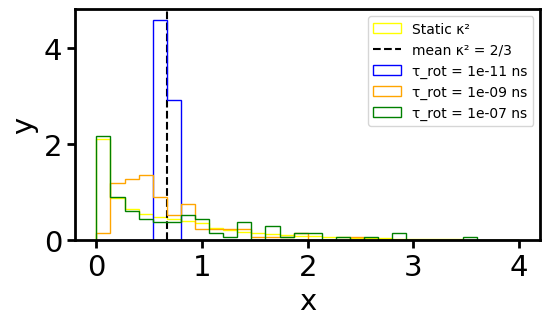

In [ ]:
rng = np.random.default_rng(2)
bins = np.linspace(0, 4, 31)
ax = fi.universal_figure(
    type_="hist",
    data=k2_values,
    bins=bins,
    density=True,
    color="yellow",
    histtype="step",
    label="Static κ²",
)
ax[0, 0].axvline(2 / 3, label="mean κ² = 2/3", color="black", linestyle="--")
rot_cor_times = [1e-11, 1e-9, 1e-7]
colors = ["blue", "orange", "green"]

for i, rot_cor_time in enumerate(rot_cor_times):
    integrals = []
    for _ in range(100):
        traj1, traj2 = kap_sq.simulate_rotational_motion(
            rot_cor_time, tau_life, dt, seed=rng
        )
        integral = kap_sq.integral_kappa_squared(traj1, traj2, dt)
        integrals.append(integral)
    fi.universal_figure(
        type_="hist",
        data=integrals,
        bins=bins,
        density=True,
        axes=ax[0, 0],
        color=colors[i],
        histtype="step",
        label=f"τ_rot = {rot_cor_time} ns",
        legend=True,
    )